In [40]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("mohankrishnathalla/sleep-health-and-daily-performance-dataset")
df = pd.read_csv(path + "/sleep_health_dataset.csv", index_col='person_id')
print(df.shape)
df.head()

(100000, 31)


,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
person_id,,,,,,,,,,,,,,,,,,,,,
1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 1 to 100000
Data columns (total 31 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   age                          100000 non-null  int64  
 1   gender                       100000 non-null  str    
 2   occupation                   100000 non-null  str    
 3   bmi                          100000 non-null  float64
 4   country                      100000 non-null  str    
 5   sleep_duration_hrs           100000 non-null  float64
 6   sleep_quality_score          100000 non-null  float64
 7   rem_percentage               100000 non-null  float64
 8   deep_sleep_percentage        100000 non-null  float64
 9   sleep_latency_mins           100000 non-null  int64  
 10  wake_episodes_per_night      100000 non-null  int64  
 11  caffeine_mg_before_bed       100000 non-null  int64  
 12  alcohol_units_before_bed     100000 non-null  float64
 13  screen_tim

In [42]:
X = pd.get_dummies(df.drop(['felt_rested', 'cognitive_performance_score','sleep_disorder_risk',
                            'country','room_temperature_celsius','bmi','sleep_latency_mins','season','weekend_sleep_diff_hrs','steps_that_day'], axis=1), drop_first=True)
y_bin = df['felt_rested']
y_reg = df['cognitive_performance_score']
y_class = df['sleep_disorder_risk']

# Regresión logística y clasificación simple

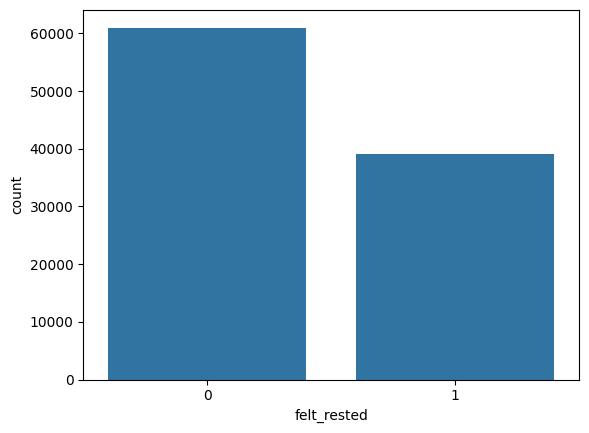

In [43]:
import seaborn as sns
import shap
import matplotlib.pyplot as plt

sns.countplot(x='felt_rested', data=df)
plt.show()

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.2, random_state=42)

In [45]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

c:\Users\whit3\OneDrive\Documentos\GitHub\iaa-pia\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [46]:
y_pred = log_model.predict(X_test)

In [47]:
from sklearn.model_selection import cross_val_score,KFold, StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
x_scaled=scaler.fit_transform(X)

log_modelo= LogisticRegression(max_iter=150000)
skf_log= StratifiedKFold(10,shuffle=True,random_state=9)

              precision    recall  f1-score   support

           0       0.76      0.82      0.79     12132
           1       0.68      0.59      0.64      7868

    accuracy                           0.73     20000
   macro avg       0.72      0.71      0.71     20000
weighted avg       0.73      0.73      0.73     20000



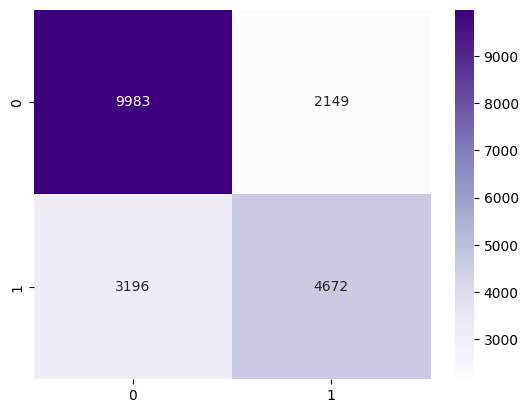

In [48]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='.0f', cmap='Purples')
plt.show()

In [49]:
'''
acc_scores= []

for train_index,test_index in skf_log.split(X,y_bin):
    X_testk = X.iloc[test_index, :]
    X_traink = X.iloc[train_index, :]
    y_testk= y_bin.iloc[test_index]
    y_traink=y_bin.iloc[train_index]

log_modelo.fit(X_traink,y_traink)

y_predk= log_modelo.predict(X_testk)

cross_val_score_lrk= cross_val_score(log_modelo, X, y_bin, cv=skf_log,scoring='accuracy')

acc_scores_lrk= accuracy_score(y_testk,y_predk)
acc_scores.append(acc_scores_lrk)
print("Cross-validation accuracy scores:", cross_val_score_lrk)
print("accuracy:",acc_scores_lrk)'''

'\nacc_scores= []\n\nfor train_index,test_index in skf_log.split(X,y_bin):\n    X_testk = X.iloc[test_index, :]\n    X_traink = X.iloc[train_index, :]\n    y_testk= y_bin.iloc[test_index]\n    y_traink=y_bin.iloc[train_index]\n\nlog_modelo.fit(X_traink,y_traink)\n\ny_predk= log_modelo.predict(X_testk)\n\ncross_val_score_lrk= cross_val_score(log_modelo, X, y_bin, cv=skf_log,scoring=\'accuracy\')\n\nacc_scores_lrk= accuracy_score(y_testk,y_predk)\nacc_scores.append(acc_scores_lrk)\nprint("Cross-validation accuracy scores:", cross_val_score_lrk)\nprint("accuracy:",acc_scores_lrk)'

# Regresión

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

In [51]:
from sklearn.linear_model import LinearRegression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [52]:
y_pred = lin_model.predict(X_test)

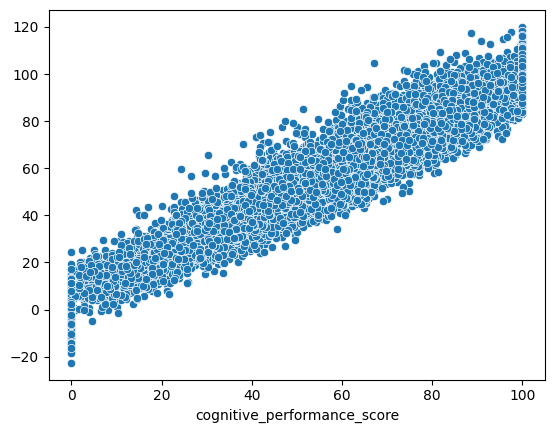

In [53]:
sns.scatterplot(x=y_test, y=y_pred)
plt.show()

# Clasificación (4 clases)

In [54]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)


In [55]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [56]:
#argumentos (# de pliegues(df5),  )
kplieuges= StratifiedKFold(10,shuffle=True, random_state=9)
score= cross_val_score(tree_model,X, y= y_class,cv=kplieuges, scoring='accuracy')
print(f'puntuación por pliegues {score}')

puntuación por pliegues [0.7587 0.7468 0.7417 0.7569 0.7458 0.7536 0.749  0.7496 0.7428 0.7542]


In [57]:
y_pred = tree_model.predict(X_test)

              precision    recall  f1-score   support

     Healthy       0.87      0.87      0.87     10892
        Mild       0.67      0.67      0.67      6673
    Moderate       0.39      0.41      0.40      1626
      Severe       0.55      0.55      0.55       809

    accuracy                           0.75     20000
   macro avg       0.62      0.63      0.62     20000
weighted avg       0.75      0.75      0.75     20000



<Axes: >

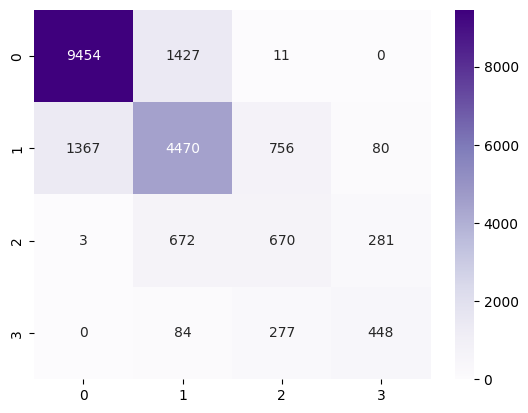

In [58]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='.0f', cmap='Purples')